# Loan Approval Prediction using Machine Learning

## Problem Statement

The objective of this project is to build a Machine Learning model that predicts whether a loan application will be approved or rejected based on the applicant's demographic, financial, and loan-related information. The model helps banks and financial institutions automate the loan approval process, reduce manual effort, minimize the risk of loan defaults, and make faster, data-driven lending decisions.

---

## Dataset

- **Training Dataset:** `train (1).csv`
- **Testing Dataset:** `test (1).csv`

---

## Data Structure

| Column Name | Description |
|-------------|-------------|
| Loan_ID | Unique identification number for each loan application |
| Gender | Gender of the applicant |
| Married | Marital status of the applicant |
| Dependents | Number of dependents |
| Education | Education level of the applicant |
| Self_Employed | Whether the applicant is self-employed |
| ApplicantIncome | Monthly income of the applicant |
| CoapplicantIncome | Monthly income of the co-applicant |
| LoanAmount | Requested loan amount |
| Loan_Amount_Term | Loan repayment period (in months) |
| Credit_History | Credit history of the applicant (1 = Good, 0 = Poor) |
| Property_Area | Location of the property (Urban, Semiurban, Rural) |
| Loan_Status | **Target Variable** (Y = Approved, N = Rejected) |

---

## Target Variable

**Loan_Status**

- **Y** → Loan Approved
- **N** → Loan Rejected

---

## Project Workflow

1. Import Required Libraries
2. Load the Dataset
3. Data Understanding
4. Data Cleaning
5. Handle Missing Values
6. Exploratory Data Analysis (EDA)
7. Feature Encoding
8. Feature Selection
9. Train-Test Split
10. Model Building
11. Model Evaluation
12. Loan Approval Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from imblearn.over_sampling import ADASYN
from sklearn.tree import DecisionTreeClassifier


In [2]:
df_train=pd.read_csv('train (1).csv')
df_test=pd.read_csv('test (1).csv')

# Data Understanding
## Traning data


In [3]:
df_train.head()


,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,1,24,male,Master,58914,2,OWN,4400,VENTURE,5.99,0.07,4,656,Yes,0
1,2,23,female,High School,45873,2,RENT,11000,VENTURE,11.01,0.24,2,634,Yes,0
2,3,29,female,Master,240947,7,MORTGAGE,10000,VENTURE,12.69,0.04,9,638,Yes,0
3,4,30,female,Bachelor,96316,10,MORTGAGE,6000,MEDICAL,13.49,0.06,8,682,No,0
4,5,29,male,Bachelor,73033,7,MORTGAGE,8000,PERSONAL,10.51,0.11,8,644,Yes,0


In [4]:
df_train.tail()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
35995,35996,23,male,Bachelor,89921,3,RENT,3500,EDUCATION,12.87,0.04,3,634,Yes,0
35996,35997,25,female,Associate,35911,2,RENT,3000,EDUCATION,6.62,0.08,4,573,No,1
35997,35998,30,male,Bachelor,72786,9,OWN,20000,EDUCATION,6.17,0.27,9,477,Yes,0
35998,35999,30,male,Associate,39629,8,RENT,6000,MEDICAL,12.99,0.15,9,689,No,0
35999,36000,27,male,Master,48917,5,RENT,14000,MEDICAL,13.11,0.29,5,563,No,1


In [5]:
print("Number of rows and columns in the training dataset:", df_train.shape)

Number of rows and columns in the training dataset: (36000, 15)


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              36000 non-null  int64  
 1   person_age                      36000 non-null  int64  
 2   person_gender                   36000 non-null  object 
 3   person_education                36000 non-null  object 
 4   person_income                   36000 non-null  int64  
 5   person_emp_exp                  36000 non-null  int64  
 6   person_home_ownership           36000 non-null  object 
 7   loan_amnt                       36000 non-null  int64  
 8   loan_intent                     36000 non-null  object 
 9   loan_int_rate                   36000 non-null  float64
 10  loan_percent_income             36000 non-null  float64
 11  cb_person_cred_hist_length      36000 non-null  int64  
 12  credit_score                    

In [7]:
df_train.describe()

,ID,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,36000.000000,36000.000000,3.600000e+04,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,18000.500000,27.763194,8.054947e+04,5.405611,9586.962861,11.013158,0.139635,5.863444,632.649583,0.222222
std,10392.449182,6.045354,8.431697e+04,6.064240,6301.447426,2.976288,0.086949,3.878709,50.292346,0.415745
min,1.000000,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,9000.750000,24.000000,4.716350e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,602.000000,0.000000
50%,18000.500000,26.000000,6.708100e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,27000.250000,30.000000,9.626075e+04,8.000000,12235.000000,13.022500,0.190000,8.000000,670.000000,0.000000
max,36000.000000,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [8]:
df_train.describe(include=object)

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,36000,36000,36000,36000,36000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,19786,10738,18730,7296,18263


In [9]:
df_train.dtypes

ID                                  int64
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [10]:
for i in df_train.columns:
    print(f"Number Of unique values in {i} is {df_train[i].nunique()}")    

Number Of unique values in ID is 36000
Number Of unique values in person_age is 58
Number Of unique values in person_gender is 2
Number Of unique values in person_education is 5
Number Of unique values in person_income is 28534
Number Of unique values in person_emp_exp is 61
Number Of unique values in person_home_ownership is 4
Number Of unique values in loan_amnt is 3742
Number Of unique values in loan_intent is 6
Number Of unique values in loan_int_rate is 1277
Number Of unique values in loan_percent_income is 64
Number Of unique values in cb_person_cred_hist_length is 29
Number Of unique values in credit_score is 335
Number Of unique values in previous_loan_defaults_on_file is 2
Number Of unique values in loan_status is 2


## Testing Data

In [11]:
df_test.head()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,1,25,female,Bachelor,84973,2,MORTGAGE,14000,VENTURE,5.42,0.16,3,634,No
1,2,24,male,Bachelor,87280,2,OWN,16000,EDUCATION,12.42,0.18,2,610,Yes
2,3,22,female,Associate,70178,0,OWN,6500,VENTURE,7.49,0.09,3,668,Yes
3,4,27,male,Bachelor,176144,1,MORTGAGE,2500,MEDICAL,8.49,0.01,6,591,Yes
4,5,26,female,Bachelor,181548,3,MORTGAGE,10000,DEBTCONSOLIDATION,15.99,0.06,3,643,No


In [12]:
df_test.tail()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
8995,8996,23,male,Associate,65677,1,RENT,9500,MEDICAL,14.65,0.14,2,605,Yes
8996,8997,25,female,Master,68132,1,MORTGAGE,5000,PERSONAL,6.24,0.07,4,579,Yes
8997,8998,24,female,Bachelor,52801,5,RENT,5000,EDUCATION,12.47,0.09,4,684,Yes
8998,8999,33,male,Master,67209,7,MORTGAGE,3500,HOMEIMPROVEMENT,10.65,0.05,5,650,Yes
8999,9000,33,male,High School,106450,10,RENT,9000,VENTURE,13.29,0.08,10,708,Yes


In [13]:
print("Number of rows and columns in the training dataset:", df_test.shape)

Number of rows and columns in the training dataset: (9000, 14)


In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              9000 non-null   int64  
 1   person_age                      9000 non-null   int64  
 2   person_gender                   9000 non-null   object 
 3   person_education                9000 non-null   object 
 4   person_income                   9000 non-null   int64  
 5   person_emp_exp                  9000 non-null   int64  
 6   person_home_ownership           9000 non-null   object 
 7   loan_amnt                       9000 non-null   int64  
 8   loan_intent                     9000 non-null   object 
 9   loan_int_rate                   9000 non-null   float64
 10  loan_percent_income             9000 non-null   float64
 11  cb_person_cred_hist_length      9000 non-null   int64  
 12  credit_score                    90

In [15]:
df_test.describe()

,ID,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
count,9000.000000,9000.000000,9.000000e+03,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,4500.500000,27.768111,7.939739e+04,5.429222,9567.936333,10.980397,0.140086,5.883667,632.445444
std,2598.220545,6.044461,6.245740e+04,6.061001,6368.689754,2.988891,0.088263,3.883845,51.008395
min,1.000000,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,421.000000
25%,2250.750000,24.000000,4.731675e+04,1.000000,5000.000000,8.580000,0.070000,3.000000,600.750000
50%,4500.500000,26.000000,6.689700e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,639.000000
75%,6750.250000,30.000000,9.459075e+04,8.000000,12250.000000,12.990000,0.190000,8.000000,670.000000
max,9000.000000,123.000000,1.661567e+06,101.000000,35000.000000,20.000000,0.560000,30.000000,805.000000


In [16]:
df_test.describe(include=object)

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,9000,9000,9000,9000,9000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,5055,2661,4713,1857,4595


In [17]:
df_test.dtypes

ID                                  int64
person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file     object
dtype: object

In [18]:
for i in df_test.columns:
    print(f"Number Of unique values in {i} is {df_test[i].nunique()}")    

Number Of unique values in ID is 9000
Number Of unique values in person_age is 50
Number Of unique values in person_gender is 2
Number Of unique values in person_education is 5
Number Of unique values in person_income is 8445
Number Of unique values in person_emp_exp is 49
Number Of unique values in person_home_ownership is 4
Number Of unique values in loan_amnt is 1295
Number Of unique values in loan_intent is 6
Number Of unique values in loan_int_rate is 1031
Number Of unique values in loan_percent_income is 56
Number Of unique values in cb_person_cred_hist_length is 28
Number Of unique values in credit_score is 294
Number Of unique values in previous_loan_defaults_on_file is 2


# Data Cleaning
## Traning data

In [19]:
df_train.duplicated().sum()

np.int64(0)

In [20]:
df_train.isna().sum()

ID                                0
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [21]:
for i in df_train.select_dtypes(include='object').columns:
    print(f"Unique values in {i} are {df_train[i].unique()}")

Unique values in person_gender are ['male' 'female']
Unique values in person_education are ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
Unique values in person_home_ownership are ['OWN' 'RENT' 'MORTGAGE' 'OTHER']
Unique values in loan_intent are ['VENTURE' 'MEDICAL' 'PERSONAL' 'HOMEIMPROVEMENT' 'DEBTCONSOLIDATION'
 'EDUCATION']
Unique values in previous_loan_defaults_on_file are ['Yes' 'No']


In [22]:
df_train['person_gender']=df_train['person_gender'].replace({'male':'Male','female':'Female'})



## Testing Data


In [23]:
df_test.duplicated().sum()

np.int64(0)

In [24]:
df_test.isna().sum()

ID                                0
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
dtype: int64

In [25]:
for i in df_test.select_dtypes(include=object):
    print(f"Unique values in {i} are {df_test[i].unique()}")

Unique values in person_gender are ['female' 'male']
Unique values in person_education are ['Bachelor' 'Associate' 'High School' 'Master' 'Doctorate']
Unique values in person_home_ownership are ['MORTGAGE' 'OWN' 'RENT' 'OTHER']
Unique values in loan_intent are ['VENTURE' 'EDUCATION' 'MEDICAL' 'DEBTCONSOLIDATION' 'PERSONAL'
 'HOMEIMPROVEMENT']
Unique values in previous_loan_defaults_on_file are ['No' 'Yes']


In [26]:
df_test['person_gender']=df_test['person_gender'].replace({'male':'Male','female':'Female'})

# Exploratory Data Analysis
## Training data

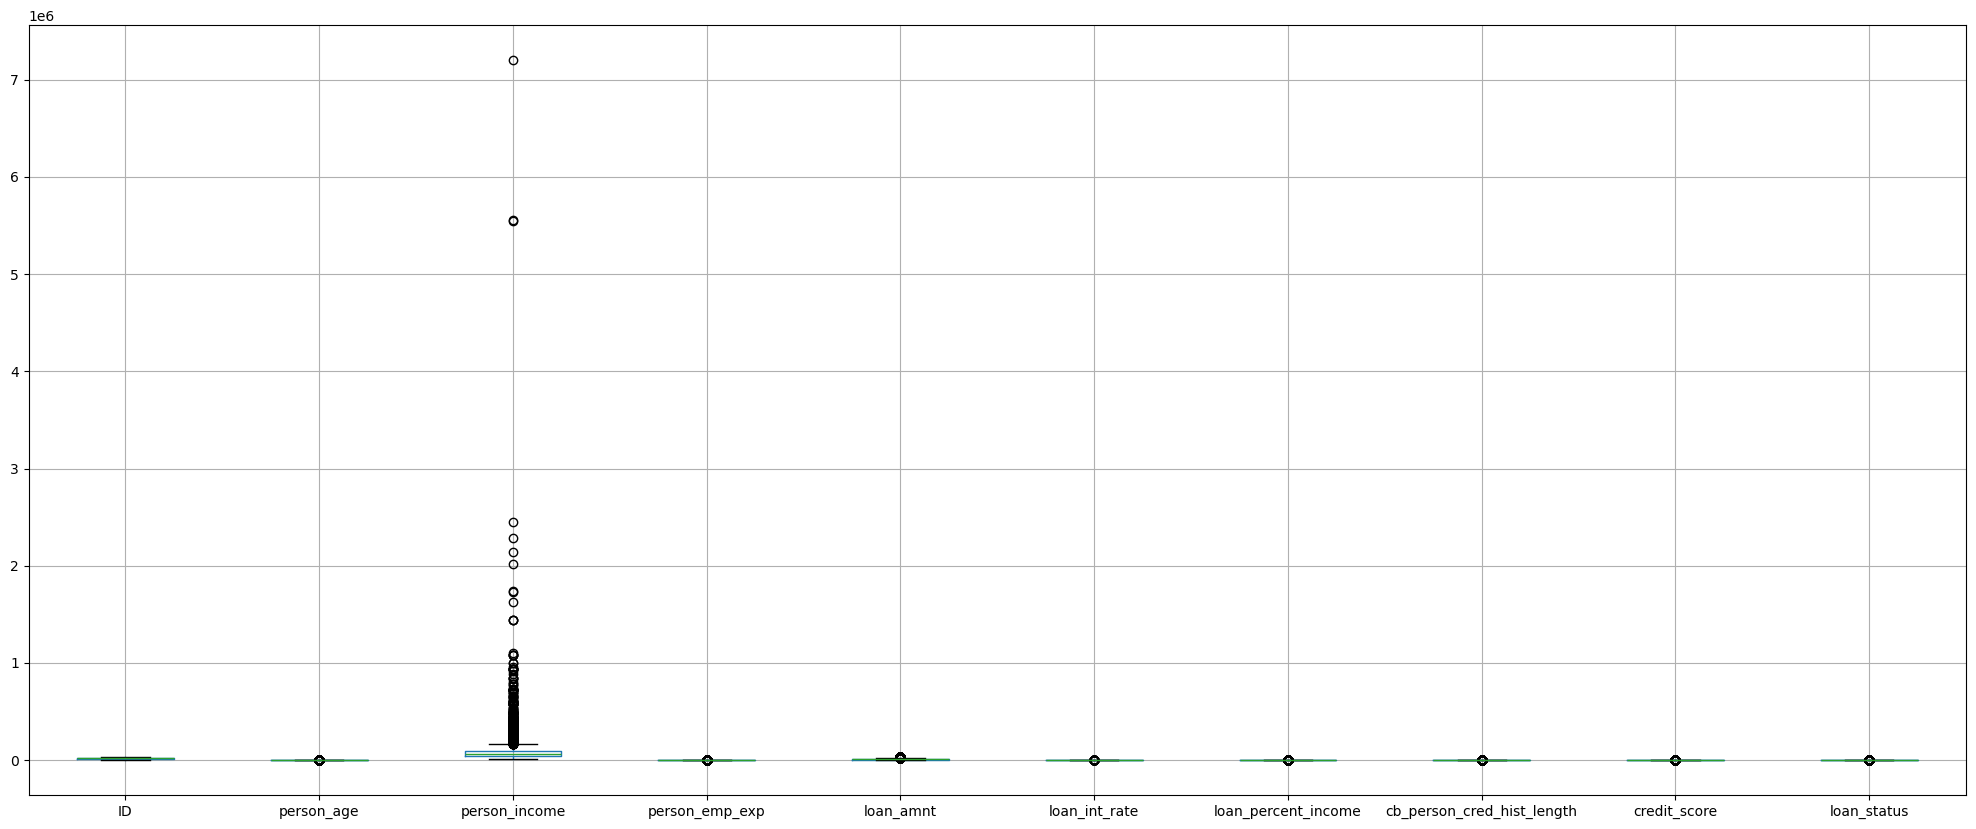

In [27]:
plt.figure(figsize=(25,10))
df_train.boxplot()
plt.show()

In [28]:
df_train.head()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,1,24,Male,Master,58914,2,OWN,4400,VENTURE,5.99,0.07,4,656,Yes,0
1,2,23,Female,High School,45873,2,RENT,11000,VENTURE,11.01,0.24,2,634,Yes,0
2,3,29,Female,Master,240947,7,MORTGAGE,10000,VENTURE,12.69,0.04,9,638,Yes,0
3,4,30,Female,Bachelor,96316,10,MORTGAGE,6000,MEDICAL,13.49,0.06,8,682,No,0
4,5,29,Male,Bachelor,73033,7,MORTGAGE,8000,PERSONAL,10.51,0.11,8,644,Yes,0


In [29]:
df_train.groupby('person_gender')['loan_status'].value_counts()

person_gender  loan_status
Female         0              12583
               1               3631
Male           0              15417
               1               4369
Name: count, dtype: int64

In [30]:
df_train.groupby('person_education')['person_income'].mean()

person_education
Associate      81281.497880
Bachelor       79789.343453
Doctorate      87824.807843
High School    80300.014208
Master         80503.347195
Name: person_income, dtype: float64

In [31]:
df_train.groupby('loan_intent')['loan_int_rate'].mean()

loan_intent
DEBTCONSOLIDATION    11.042249
EDUCATION            10.884049
HOMEIMPROVEMENT      11.197218
MEDICAL              11.117146
PERSONAL             10.998278
VENTURE              10.923216
Name: loan_int_rate, dtype: float64

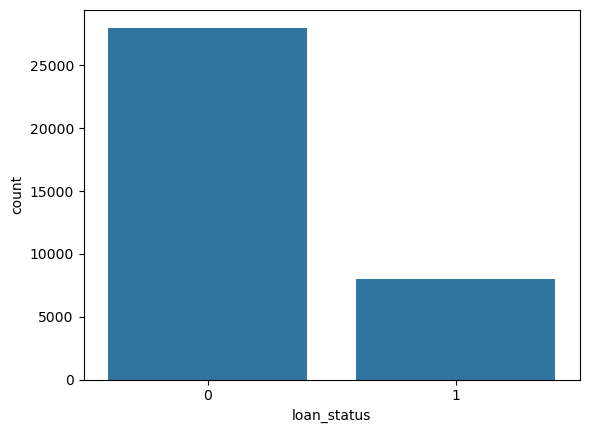

In [32]:
sns.countplot(x='loan_status',data=df_train)
plt.show()

# Testing data

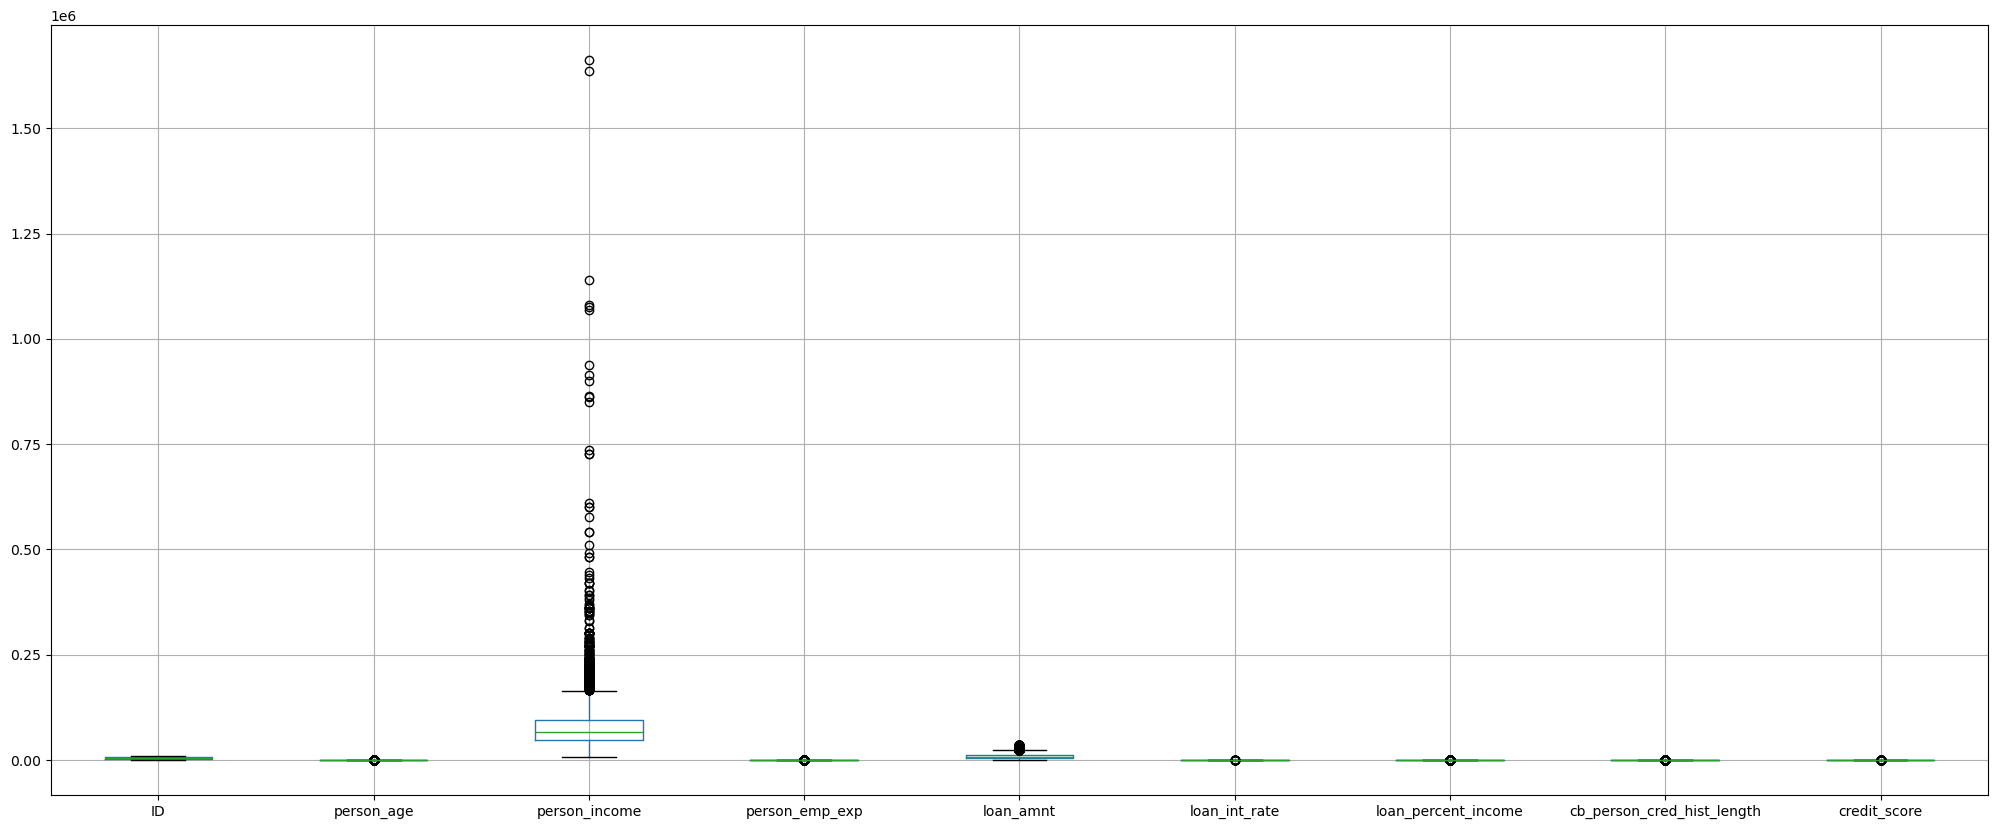

In [33]:
plt.figure(figsize=(25,10))
df_test.boxplot()
plt.show()

In [34]:
df_test.groupby('person_gender')['credit_score'].value_counts()

person_gender  credit_score
Female         634             49
               637             42
               663             42
               639             41
               654             39
                               ..
Male           748              1
               751              1
               753              1
               755              1
               784              1
Name: count, Length: 550, dtype: int64

In [35]:
df_test.groupby('person_education')['person_income'].mean()

person_education
Associate      78016.157403
Bachelor       79356.186020
Doctorate      84522.504505
High School    79934.472874
Master         80446.436831
Name: person_income, dtype: float64

In [36]:
df_test.groupby('loan_intent')['loan_int_rate'].mean()

loan_intent
DEBTCONSOLIDATION    11.013558
EDUCATION            10.984529
HOMEIMPROVEMENT      11.216266
MEDICAL              10.945475
PERSONAL             10.908786
VENTURE              10.912395
Name: loan_int_rate, dtype: float64

# Encoding

In [37]:
df_train.head()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,1,24,Male,Master,58914,2,OWN,4400,VENTURE,5.99,0.07,4,656,Yes,0
1,2,23,Female,High School,45873,2,RENT,11000,VENTURE,11.01,0.24,2,634,Yes,0
2,3,29,Female,Master,240947,7,MORTGAGE,10000,VENTURE,12.69,0.04,9,638,Yes,0
3,4,30,Female,Bachelor,96316,10,MORTGAGE,6000,MEDICAL,13.49,0.06,8,682,No,0
4,5,29,Male,Bachelor,73033,7,MORTGAGE,8000,PERSONAL,10.51,0.11,8,644,Yes,0


In [38]:
df_train['person_gender']=df_train['person_gender'].map({'Male':1,'Female':0})
df_test['person_gender']=df_test['person_gender'].map({'Male':1,'Female':0})

df_train['person_education']=df_train['person_education'].map({
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
})

df_test['person_education']=df_test['person_education'].map({
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
})


df_train['loan_intent']=df_train['loan_intent'].map({
    'HOMEIMPROVEMENT': 0,
    'DEBTCONSOLIDATION': 1,
    'PERSONAL': 2,
    'VENTURE': 3,
    'MEDICAL': 4,
    'EDUCATION': 5
})
df_test['loan_intent']=df_test['loan_intent'].map({
    'HOMEIMPROVEMENT': 0,
    'DEBTCONSOLIDATION': 1,
    'PERSONAL': 2,
    'VENTURE': 3,
    'MEDICAL': 4,
    'EDUCATION': 5
})

df_train['previous_loan_defaults_on_file']=df_train['previous_loan_defaults_on_file'].map({
    'Yes':1,'No':0})
df_test['previous_loan_defaults_on_file']=df_test['previous_loan_defaults_on_file'].map({
    'Yes':1,'No':0})

In [39]:
df_train=pd.get_dummies(df_train,columns=['person_home_ownership'],drop_first=True, dtype=int)


In [40]:
df_test=pd.get_dummies(df_test,columns=['person_home_ownership'],drop_first=True, dtype=int)

In [41]:
df_train.head()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,1,24,1,3,58914,2,4400,3,5.99,0.07,4,656,1,0,0,1,0
1,2,23,0,0,45873,2,11000,3,11.01,0.24,2,634,1,0,0,0,1
2,3,29,0,3,240947,7,10000,3,12.69,0.04,9,638,1,0,0,0,0
3,4,30,0,2,96316,10,6000,4,13.49,0.06,8,682,0,0,0,0,0
4,5,29,1,2,73033,7,8000,2,10.51,0.11,8,644,1,0,0,0,0


In [42]:
df_test.head()

,ID,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,1,25,0,2,84973,2,14000,3,5.42,0.16,3,634,0,0,0,0
1,2,24,1,2,87280,2,16000,5,12.42,0.18,2,610,1,0,1,0
2,3,22,0,1,70178,0,6500,3,7.49,0.09,3,668,1,0,1,0
3,4,27,1,2,176144,1,2500,4,8.49,0.01,6,591,1,0,0,0
4,5,26,0,2,181548,3,10000,1,15.99,0.06,3,643,0,0,0,0


# Split the data

In [43]:
X_train=df_train.drop(columns='loan_status')
y_train=df_train['loan_status']
X_test=df_test

# Feature Selection

In [44]:
dtr=DecisionTreeClassifier(random_state=42)
dtr.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
dtr_model=pd.Series(dtr.feature_importances_, index=X_train.columns)
dt_imp=dtr_model.sort_values(ascending=False).head(10).index
dt_imp

Index(['previous_loan_defaults_on_file', 'loan_int_rate',
       'loan_percent_income', 'person_income', 'credit_score', 'ID',
       'person_home_ownership_RENT', 'loan_intent', 'loan_amnt', 'person_age'],
      dtype='object')

# Sampling

In [46]:
y_train.value_counts()

loan_status
0    28000
1     8000
Name: count, dtype: int64

In [48]:
ada=ADASYN(random_state=42)
X_ada, y_ada = ada.fit_resample(X_train[dt_imp], y_train)

In [49]:
y_ada.value_counts()

loan_status
1    30113
0    28000
Name: count, dtype: int64

In [50]:
svc=AdaBoostClassifier(random_state=42)
svc.fit(X_ada,y_ada)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [53]:
y_pred=svc.predict(X_test[dt_imp])
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9000,))

In [55]:
submission=pd.DataFrame({'ID': df_test['ID'], 'loan_status': y_pred})

In [56]:
submission.to_csv("submission_final.csv", index=False)

print("Submission file created successfully!")
submission.head()

Submission file created successfully!


,ID,loan_status
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
